In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings 

In [3]:
df=pd.read_csv('data/stud.csv')

In [4]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
x=df.drop(columns=['math_score'])

In [6]:
y=df['math_score']

In [7]:
y

0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math_score, Length: 1000, dtype: int64

In [12]:
#create column transformers with 3 types of transformers
num_features=x.select_dtypes(exclude='object').columns
cat_features=x.select_dtypes(include='object').columns

from sklearn.preprocessing import OneHotEncoder,StandardScaler
from sklearn.compose import ColumnTransformer

numeric_tranformer=StandardScaler()
oh_transformer=OneHotEncoder()

preprocessor=ColumnTransformer(
    [
        ("OneHotEncoder",oh_transformer,cat_features),
        ("StandardScaler",numeric_tranformer,num_features)
    ]
)

C:\Users\vedan\AppData\Local\Temp\ipykernel_1596\614956184.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_features=x.select_dtypes(include='object').columns


In [ ]:
x=preprocessor.fit_transform(x)

ValueError: Specifying the columns using strings is only supported for dataframes.

In [15]:
x

array([[ 1.        ,  0.        ,  0.        , ...,  1.        ,
         0.19399858,  0.39149181],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         1.42747598,  1.31326868],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.77010859,  1.64247471],
       ...,
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.12547206, -0.20107904],
       [ 1.        ,  0.        ,  0.        , ...,  0.        ,
         0.60515772,  0.58901542],
       [ 1.        ,  0.        ,  0.        , ...,  1.        ,
         1.15336989,  1.18158627]], shape=(1000, 19))

In [17]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train.shape,x_test.shape

((800, 19), (200, 19))

In [19]:
def evaluate_model(true,predicted):
    mae=mean_absolute_error(true,predicted)
    mse=mean_squared_error(true,predicted)
    rmse=np.sqrt(mse)
    r2score=r2_score(true,predicted)
    return mae,rmse,r2score

In [21]:
models={
    "Linear Regression":LinearRegression(),
    "Lasso":Lasso(),
    "K-Neighbors regressor":KNeighborsRegressor(),
    "Ridge":Ridge(),
    "Decision Tree":DecisionTreeRegressor(),
    "Random Forest":RandomForestRegressor(),
    "XGB Regressor":XGBRegressor(),
    "CatBoosting Regressor":CatBoostRegressor(),
    "AdaBoost Regressor":AdaBoostRegressor()
}
model_list=[]
r2_list=[]
for i in range(len(list(models))):
    model=list(models.values())[i]
    model.fit(x_train,y_train)
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)

    model_train_mae,model_train_rmse,model_train_r2_score=evaluate_model(y_train,y_train_pred)
    model_test_mae,model_test_rmse,model_test_r2_score=evaluate_model(y_test,y_test_pred)

    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])

    print("Model Performance for the training set:")
    print(f"Root mean squared error : {model_train_rmse}")
    print(f"Mean Absolute Error : {model_train_mae}")
    print(f"R2 Score : {model_train_r2_score}")

    print("-"*10)

    print("Model Performance for the testing set:")
    print(f"Root mean squared error : {model_test_rmse}")
    print(f"Mean Absolute Error : {model_test_mae}")
    print(f"R2 Score : {model_test_r2_score}")

    r2_list.append(model_test_r2_score)

    print("="*20)


Linear Regression
Model Performance for the training set:
Root mean squared error : 5.323050852720514
Mean Absolute Error : 4.266711846071957
R2 Score : 0.8743172040139593
----------
Model Performance for the testing set:
Root mean squared error : 5.393993869732843
Mean Absolute Error : 4.21476314247485
R2 Score : 0.8804332983749565
Lasso
Model Performance for the training set:
Root mean squared error : 6.593815587795568
Mean Absolute Error : 5.206302661246528
R2 Score : 0.8071462015863455
----------
Model Performance for the testing set:
Root mean squared error : 6.519694535667422
Mean Absolute Error : 5.157881810347764
R2 Score : 0.8253197323627852
K-Neighbors regressor
Model Performance for the training set:
Root mean squared error : 5.707683417990174
Mean Absolute Error : 4.516749999999999
R2 Score : 0.8554978341651085
----------
Model Performance for the testing set:
Root mean squared error : 7.253040741647602
Mean Absolute Error : 5.621
R2 Score : 0.7838129945787431
Ridge
Model P

In [23]:
r2=pd.DataFrame(list(zip(model_list,r2_list)),columns=['Model','R2 Score']).sort_values(by=['R2 Score'],ascending=False)
r2

,Model,R2 Score
3,Ridge,0.880593
0,Linear Regression,0.880433
5,Random Forest,0.852149
7,CatBoosting Regressor,0.851632
8,AdaBoost Regressor,0.844057
6,XGB Regressor,0.827797
1,Lasso,0.825320
2,K-Neighbors regressor,0.783813
4,Decision Tree,0.742375


In [26]:
lin_model=LinearRegression(fit_intercept=True)
lin_model.fit(x_train,y_train)
y_pred=lin_model.predict(x_test)
score=r2_score(y_test,y_pred)*100
print(f"Accuracy of the model is {score}")

Accuracy of the model is 88.04332983749565


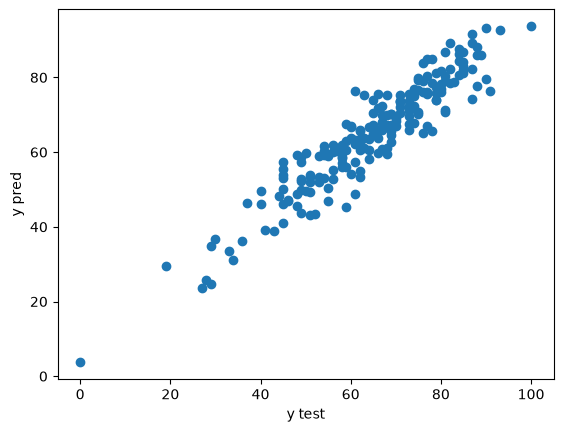

In [27]:
plt.scatter(y_test,y_pred)
plt.xlabel("y test")
plt.ylabel("y pred")
plt.show()